## Porownanie wlasnej listy z rozwiazaniami konkursowymi Kaggle

Wybrana lista: Lista 5 (Ensemble), zadanie Salud 2030, predykcja poziomu otylosci.

Konkurs Kaggle: Playground Series, Season 4, Episode 2, Multi-Class Prediction of Obesity Risk.
Link: https://www.kaggle.com/competitions/playground-series-s4e2

## 1. Wybor pracy konkursowej

Wybralem Liste 5 (otylosc), gdzie przewidywalem poziom otylosci na podstawie ankiet o nawykach. Na Kaggle znalazlem konkurs Playground Series S4E2, ktory uzywa dokladnie tego samego zbioru (te same kolumny i 7 klas), tylko rozszerzonego sztucznie. To ten sam typ problemu, czyli klasyfikacja wieloklasowa.

Do porownania wzialem trzy notebooki:
1. "easy-peasy-eda-xgboost" - preprocessing, tuning i trening
https://www.kaggle.com/code/lucamassaron/easy-peasy-eda-xgboost-is-all-you-need

2. "visual-eda-lgbm-starter" - eda
https://www.kaggle.com/code/ddosad/ps4e2-visual-eda-lgbm-obesity-risk

3. "random-forest-xgboost-96.2" - preprocessing,
https://www.kaggle.com/code/hardikgarg03/obesity-risk-random-forest-xgboost-96-2-accuracy

Najwazniejsze roznica jest taka, ze na Kaggle liczy sie tylko accuracy na ukrytym tescie. U mnie model mial trafic do przychodni, wiec wazny byl tez czas dzialania, rozmiar i zrozumienie decyzji.

## 2. Eksploracyjna analiza danych (EDA)

### Moje podejscie

Zaczalem standardowo: sprawdzilem rozklad klas w targecie, duplikaty i puste wartosci.

Potem przeszedlem do wagi i wzrostu, bo chcialem zdecydowac czy je zostawic. Okazalo sie, ze policzone z nich BMI prawie samo wyznacza klase, bo drzewo trenowane na samym BMI dalo az 93.5 procent dokladnosci, a na wykresie pudelkowym klasy w ogole sie nie nakladaly. 

Na koniec obejrzalem rozklady cech numerycznych i kategorycznych wzgledem klasy, zeby zobaczyc co najbardziej je rozroznia.

In [ ]:
# MOJ KOD:
df_check = df.copy()
df_check['BMI'] = df_check['Weight'] / (df_check['Height'] ** 2)

X_bmi = df_check[['BMI']]
y_check = df_check['NObeyesdad']
scores = cross_val_score(DecisionTreeClassifier(random_state=42), X_bmi, y_check, cv=5)
print(f"Accuracy drzewa na samym BMI: {scores.mean():.4f}")  # 0.935

df = df.drop(columns=['Weight', 'Height'])

### Notebook konkursowy (visual-eda-lgbm-starter)

Notebook konkursowy robi EDA znacznie szersza wizualnie. Ma generyczna funkcje summary() liczaca dla kazdej kolumny braki, unikaty, statystyki i skosnosc, oraz funkcje showplot() generujaca komplet wykresow per cecha. Pokazuje rozklady wszystkich cech numerycznych naraz, heatmape korelacji, analize outlierow.
Robi dokladnie odwrotna decyzje niz ja w sprawie BMI: liczy BMI i opisuje je jako silny predyktor, traktujac to jako zaleta.

In [ ]:
# KOD KONKURSOWY (visual-eda): generyczna funkcja podsumowujaca zbior
def summary(df):
    summ = pd.DataFrame(df.dtypes, columns=['dtypes'])
    summ['missing#'] = df.isna().sum()
    summ['uniques'] = df.nunique().values
    summ['mean'] = df.mean(numeric_only=True)
    summ['skew'] = df.skew(numeric_only=True)
    return summ

df_train['BMI'] = df_train['Weight'] / (df_train['Height'] ** 2)
df_train.groupby('NObeyesdad')['BMI'].describe()

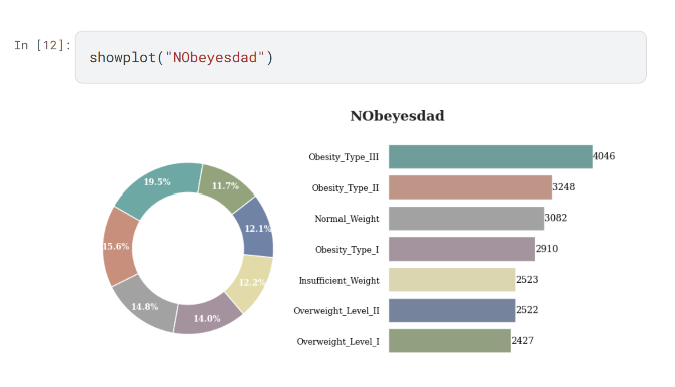

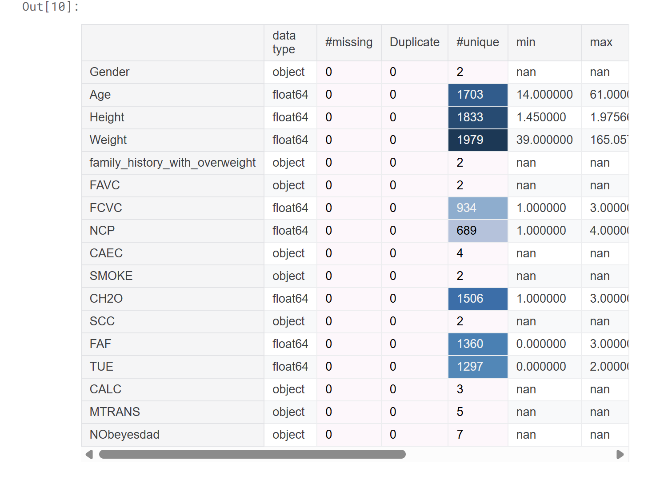

### Porownanie i wnioski

Są dwie głowne różnice: 

1. Notebook konkursowy ogarnia wiecej cech automatycznie, ma gotowe funkcje do wielokrotnego uzytku (summary, showplot) i porownuje rozklady miedzy zbiorem treningowym a testowym, czego u mnie nie ma, bo nie mialem osobnego zbioru testowego.

2. Dotyczy BMI. Ja policzylem, ze BMI samo daje 93.5 procent dokladnosci, i wlasnie dlatego wyrzucilem wage i wzrost, zeby model uczyl sie ze stylu zycia. To pasuje do sensu zadania, bo kierowałem się tym, że trenujemy model na codziennych nawykach. Notebook konkursowy liczy dokladnie to samo BMI, ale zostawia je jako najmocniejsza ceche, bo jemu zalezy tylko na wyniku w rankingu.

**Co moglbym wziac:** funkcja summary() to wygodny pierwszy krok i warto ja miec pod reka. Porownanie rozkladow treningu i testu ma sens zawsze, gdy zbior testowy jest osobny.

## 3. Preprocessing

### Moje podejscie

Po usunieciu duplikatow i kolumn Weight/Height zbudowalem ColumnTransformer: StandardScaler na cechach numerycznych i OneHotEncoder na kategorycznych. Podzial ze stratyfikacja po klasie. Nie tworzylem nowych cech i nie ruszalem outlierow.

In [ ]:
# MOJ KOD: ColumnTransformer, stratyfikowany split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

### Notebooki konkursowe

Dwie rzeczy ktorych ja nie zrobilem.

Pierwsza, feature engineering. Autor tworzy 5 nowych cech z istniejacych. To sa kombinacje cech, ktore maja oddac sensowne wzorce zachowan.

Druga, transformacja rozkladow i outliery (random-forest-96.2). Autor stosuje PowerTransformer yeo-johnson na cechach, zeby zblizyc rozklady do normalnego, oraz jawnie usuwa outliery metoda IQR.

In [ ]:
# KOD KONKURSOWY (easy-peasy): inzynieria cech
train['BMI'] = train['Weight'] / (train['Height'] ** 2)
train['Physical_Activity_Level'] = train['FAF'] - train['TUE']
train['Meal_Habits'] = train['FCVC'] * train['NCP']
train['Healthy_Nutrition_Habits'] = train['FCVC'] / (2 * train['FAVC_no'] - 1)
train['Tech_Usage_Score'] = train['TUE'] / train['Age']

In [ ]:
# KOD KONKURSOWY (random-forest-96.2): yeo-johnson + usuwanie outlierow IQR
pt = PowerTransformer(method='yeo-johnson')
train_features_scaled = pt.fit_transform(train_features)

def remove_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    return data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

train_scaled = remove_outliers(train_scaled)

### Porownanie i wnioski

Z BMI jest tu ta sama historia co przy EDA, tylko odwrotnie autor dodaje je jako pierwsza nowa ceche, zeby podbic wynik, a ja je usunalem, bo zalezalo mi na sensie modelu, a nie na rankingu.

Poza tym notebook konkursowy tworzy kilka innych cech laczonych ze soba. Tych akurat moglbym uzyc u siebie, bo nie psuja sensu zadania, a moga troche poprawic wynik.

Drugi notebook robi jeszcze dwie rzeczy, ktorych w ogole nie tknalem: wyrownuje rozklady cech (yeo-johnson) i wycina outliery. Dla moich modeli drzewiastych wyrownywanie rozkladu prawie nic nie daje, bo drzewom to obojetne, ale mialoby sens przy regresji logistycznej, ktora tez u siebie mialem. Wycinania outlierow akurat bym nie ruszal, bo w danych ankietowych nietypowy wynik to czesto realny pacjent, ktorego model i tak ma obsluzyc.

**Co moglbym wziac**: kilka cech laczonych i ewentualnie wyrownanie rozkladu cech pod liniowy model

## 4. Optymalizacja hiperparametrow

### Moje podejscie

Przeszukiwalem hiperparametry recznie, zagniezdzonymi petlami, a wyniki czytalem z tablic.

In [ ]:
# MOJ KOD: reczny grid po dwoch parametrach, ocena na hold-out
lr_values = [0.01, 0.05, 0.1, 0.3, 1.0]
n_values = [50, 100, 200, 500]

grid_results = []
for lr in lr_values:
    for n in n_values:
        r = evaluate_model(
            f'GBM(lr={lr}, n={n})',
            GradientBoostingClassifier(n_estimators=n, learning_rate=lr,
                                       max_depth=3, random_state=42),
            X_train, X_test, y_train, y_test
        )
        grid_results.append(r)

### Notebooki konkursowe

Zamiast recznej siatki uzywaja Optuny, ktora sama inteligentnie szuka dobrych parametrow zamiast sprawdzac po kolei wszystkie z gory ustalone wartosci. "Easy-peasy" definiuje jedna funkcje, w ktorej naraz stroi dziesiec parametrow, w tym regularyzacje w skali logarytmicznej.

In [ ]:
# KOD KONKURSOWY (easy-peasy): Optuna z TPESampler, 10 parametrow naraz
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    params = {
        'grow_policy': trial.suggest_categorical('grow_policy', ["depthwise", "lossguide"]),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-9, 0.5),
        'subsample': trial.suggest_float('subsample', 0.3, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'max_depth': trial.suggest_int('max_depth', 0, 16),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-9, 100.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-9, 100.0, log=True),
    }
    # ... trening i zwrot metryki CV

### Porownanie i wnioski

**Liczba parametrow:** Ja stroilem dwa, oni dziesiec naraz. Recznie nie da sie przejsc dziesieciu parametrow. Optuna nie sprawdza wszystkiego, tylko sama celuje w obiecujace ustawienia.

**Sposob szukania:** Moja siatka jest sztywna i ustalona z gory. Optuna uczy sie po drodze, ktore wartosci daja dobry wynik, i kolejne proby kieruje wlasnie tam.

**Sposob oceny:** Ja sprawdzalem kazda kombinacje na jednym tescie, wiec moglem dopasowac parametry do tego konkretnego podzialu. Oni oceniaja kazda probe walidacja krzyzowa, czyli na kilku podzialach, przez co wybor jest pewniejszy.

**Co moglbym wziac:** Zamiana recznych petli na Optune (z ocena przez walidacje krzyzowa) poprawilaby i jakosc, i wiarygodnosc doboru.

## 5. Uczenie modelu

### Moje podejscie

Trenowalem szeroki przeglad modeli zespolowych z biblioteki sklearn: Bagging (plytkie drzewa, glebokie drzewa, regresja logistyczna), AdaBoost, GradientBoosting, Voting (hard i soft) oraz Stacking z meta-modelem. Kazdy model trenowany byl raz, na jednym podziale train/test.

In [ ]:
# MOJ KOD: Stacking na pojedynczym podziale train/test
base_models = [
    ('tree', DecisionTreeClassifier(random_state=42)),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42)),
    ('gbm', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                       max_depth=3, random_state=42)),
]
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5
)
# trening jednokrotny na X_train, ocena na X_test

### Notebooki konkursowe

Dwie roznice. Pierwsza to wybor modelu: zamiast GradientBoostingu ze sklearna uzywaja gotowych bibliotek do boostingu (LightGBM, XGBoost, CatBoost), ktore sa szybsze i zwykle daja lepszy wynik na danych tabelarycznych. Druga to sposob treningu: dziela dane na kilka czesci i kazda obserwacje przewiduja modelem, ktory jej wczesniej nie widzial.

In [ ]:
# KOD KONKURSOWY: StratifiedKFold + OOF + LightGBM
cv = StratifiedKFold(5, shuffle=True, random_state=0)

lgb = LGBMClassifier(objective="multiclass", num_class=7,
                     learning_rate=0.025, n_estimators=500,
                     max_depth=9, colsample_bytree=0.40, subsample=0.85)

cv_splits = cv.split(train, y=target_numeric)
cv_preds = cross_val_predict(lgb, train, target_numeric, cv=cv_splits)
print(classification_report(target_numeric, cv_preds))

In [ ]:
# KOD KONKURSOWY: petla OOF z usrednianiem predykcji testu po foldach
cv_test_preds = np.zeros(len(test))
for train_idx, val_idx in cv.split(train, y=target_numeric):
    model.fit(train.iloc[train_idx], target_numeric.iloc[train_idx])
    cv_train_preds[val_idx] = model.predict(train.iloc[val_idx])
    cv_test_preds += model.predict(test) / cv.n_splits

### Porownanie i wnioski

**Ocena treningu:** Ja sprawdzam model na jednym podziale, wiec wynik zalezy od tego konkretnego losowania. Oni licza srednia z kilku podzialow, przez co ocena jest pewniejsza.

**Wybor modelu:** GradientBoosting ze sklearna jest wolniejszy i slabszy od LightGBM czy XGBoost, ktore sa robione pod dane tabelaryczne. U mnie GBM dawal 82.6 procent przy 17 ms na predykcje, a biblioteki konkursowe pewnie dalyby wyzszy wynik i to szybciej.

**Co moglbym wziac:** zamienic sklearnowy GBM na LightGBM i oceniac modele na kilku podzialach zamiast jednym. Dalo by to i lepszy wynik, i uczciwsze porownanie modeli. 

## 6. Ewaluacja

### Moje podejscie

Nie patrzylem tylko na skutecznosc. Dla kazdego modelu liczylem accuracy, balanced accuracy, F1 makro, pewnosc modelu, czas predykcji i rozmiar modelu. Na koniec zestawilem accuracy z czasem predykcji na wykresie i wybralem model pod wdrozenie. Wygral GradientBoosting, ale nie dlatego ze mial najwyzsze accuracy (bagging mial 84.1 procent), tylko dlatego ze laczyl niezle accuracy 82.6 procent z szybka predykcja i dobrze dobrana pewnoscia.

In [ ]:
# MOJ KOD: ewaluacja wielokryterialna pod wdrozenie (skrot funkcji)
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([('prep', preprocessor), ('clf', model)]).fit(X_train, y_train)
    times = [ (lambda t0: (pipe.predict(X_test), time.perf_counter()-t0)[1])
              (time.perf_counter()) for _ in range(10) ]
    y_pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'confidence': np.mean(np.max(proba, axis=1)),   # pewnosc modelu
        'pred_time_ms': np.mean(times) * 1000,          # czas predykcji
    }

### Notebooki konkursowe

Notebooki konkursowe patrza na model glownie przez accuracy, uzupelnione o raport z metrykami i macierz pomylek. Jedyna rzecz, ktorej ja nie mialem, to SHAP w "easy-peasy", czyli pokazanie, ktora cecha i jak mocno wplynela na decyzje modelu, osobno dla kazdej klasy.

In [ ]:
# KOD KONKURSOWY (easy-peasy): SHAP, wklad cech per klasa
import shap
for k, target_label in enumerate(target_encoder.classes_):
    shap.summary_plot(shap_values[:, k, :-1], train.values,
                      plot_type="violin", feature_names=feature_names, show=False)
    plt.show()

### Porownanie i wnioski

Notebooki konkursowe patrza tylko na accuracy, bo o to chodzi w konkursie. Ja ocenialem model jak produkt do wdrozenia: obok accuracy patrzylem na czas predykcji, rozmiar i pewnosc, i dlatego odrzucilem model o wyzszym accuracy (bagging, 84.1 procent) na rzecz tanszego i lepiej dobranego GradientBoostingu.

Brakowalo mi za to jednej rzeczy: zrozumienia pojedynczej decyzji. Ja patrzylem, ktore cechy sa wazne dla calego modelu, a SHAP z pokazuje to dokladniej, dla kazdej klasy i nawet dla pojedynczego pacjenta.

**Co moglbym wziac:** SHAP, wprost do przeniesienia. U mnie mialby sens, bo lekarz patrzacy na decyzje modelu chcialby wiedziec, ktore konkretnie nawyki wepchnely danego pacjenta do grupy ryzyka.

## 7. Podsumowanie

Na wynik w konkursie najmocniej wplywaja dwie rzeczy, ktorych u mnie brakowalo: tworzenie nowych cech (zwlaszcza BMI, ktore na Kaggle prawie wyznacza klase) oraz lepszy wybor modelu i strojenia (LightGBM albo XGBoost z Optuna i walidacja krzyzowa zamiast GradientBoostingu ze sztywna siatka). Wlasnie preprocessing, hiperparametry i trening sa etapami, w których mógłym najwięcej skorzystąc stosując sposoby notebooków konkursowych.

Z drugiej strony czesc roznic to nie sa braki, tylko skutek innego celu. Konkurs goni za jedna liczba na ukrytym tescie. Moj model mial trafic do przychodni, byc tani i zrozumialy, dlatego swiadomie wyrzucilem BMI i patrzylem na czas oraz rozmiar modelu, czego konkurs w ogole nie robi.

Co konkretnie moglbym przeniesc do swojej listy: Optune zamiast recznych petli, ocene na kilku podzialach zamiast jednym, LightGBM jako szybszy i lepszy model, kilka nowych cech laczonych i SHAP do tlumaczenia decyzji lekarzowi. Wszystkie te zmiany pasuja do mojego zadania, plus przy decyzji pilnowanie czasu predykcji i rozmiaru, ktory dla nas wciaz sie liczy.